<a href="https://colab.research.google.com/github/rukkhan69/Netflix-Titles-Dataset-Exploratory-Data-Analysis-Report/blob/main/ProjectPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries & Load Dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
df['month_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.month
print(df.shape)
df.head()

(8807, 14)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


2. Data Cleaning

In [ ]:
df_clean = df.dropna(subset=['rating', 'duration'])
print("Cleaned shape:", df_clean.shape)
df.isnull().sum()

Cleaned shape: (8800, 14)


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


3. Content Type Distribution (Donut)

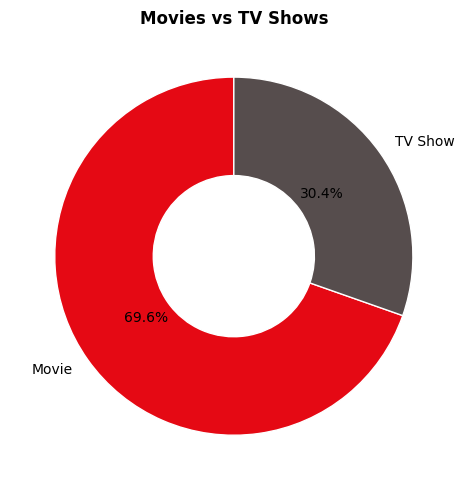

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
counts = df['type'].value_counts()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=['#E50914', '#564d4d'], startangle=90,
       wedgeprops=dict(width=0.55, edgecolor='white'))
ax.set_title('Movies vs TV Shows', fontweight='bold')
plt.tight_layout(); plt.show()


4. Top 10 Content-Producing Countries

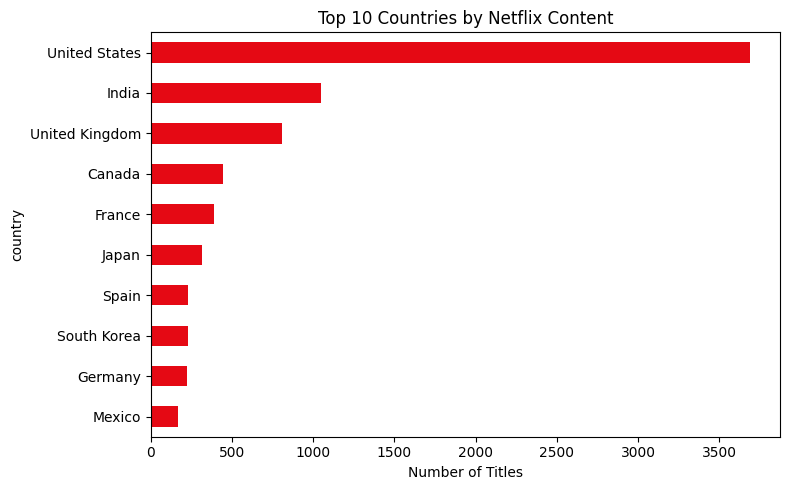

In [ ]:
top_countries = (df['country'].str.split(',')
                 .explode().str.strip()
                 .value_counts().head(10))
top_countries[::-1].plot(kind='barh', figsize=(8,5), color='#E50914')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.tight_layout(); plt.show()

5. Content Added by Year

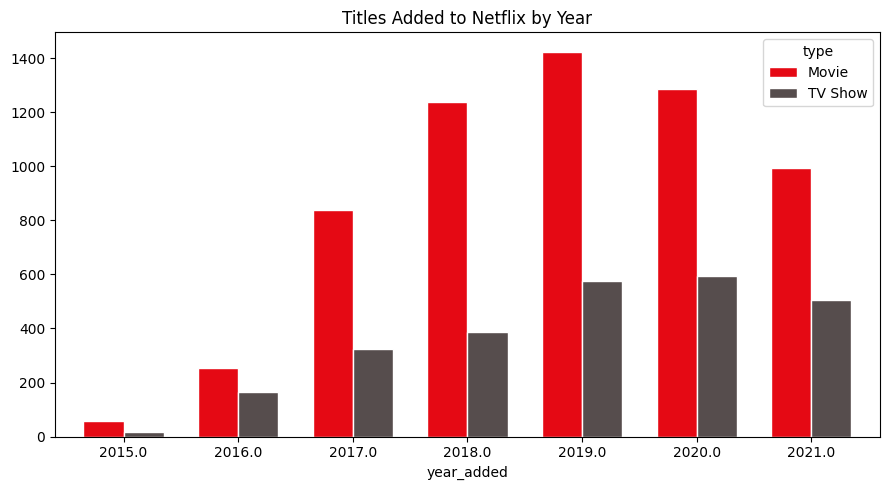

In [ ]:
year_type = (df.dropna(subset=['year_added'])
             .groupby(['year_added','type'])
             .size().unstack(fill_value=0))
year_type[year_type.index >= 2015].plot(
    kind='bar', figsize=(9,5), color=['#E50914','#564d4d'],
    edgecolor='white', width=0.7)
plt.title('Titles Added to Netflix by Year')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


6. Rating Distribution

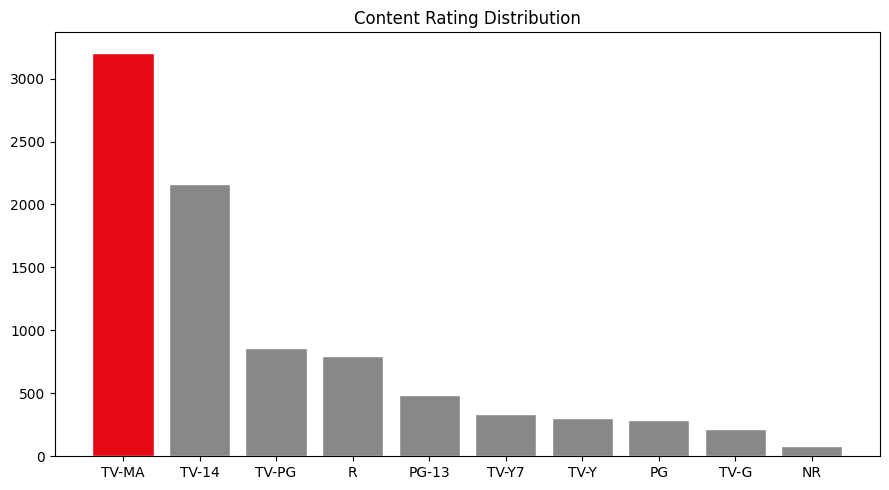

In [ ]:
ratings = df['rating'].value_counts().dropna().head(10)
colors = ['#E50914' if i==0 else '#888888' for i in range(len(ratings))]
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(ratings.index, ratings.values, color=colors, edgecolor='white')
ax.set_title('Content Rating Distribution')
plt.tight_layout(); plt.show()

11. Boxplot — Movie Duration by Rating

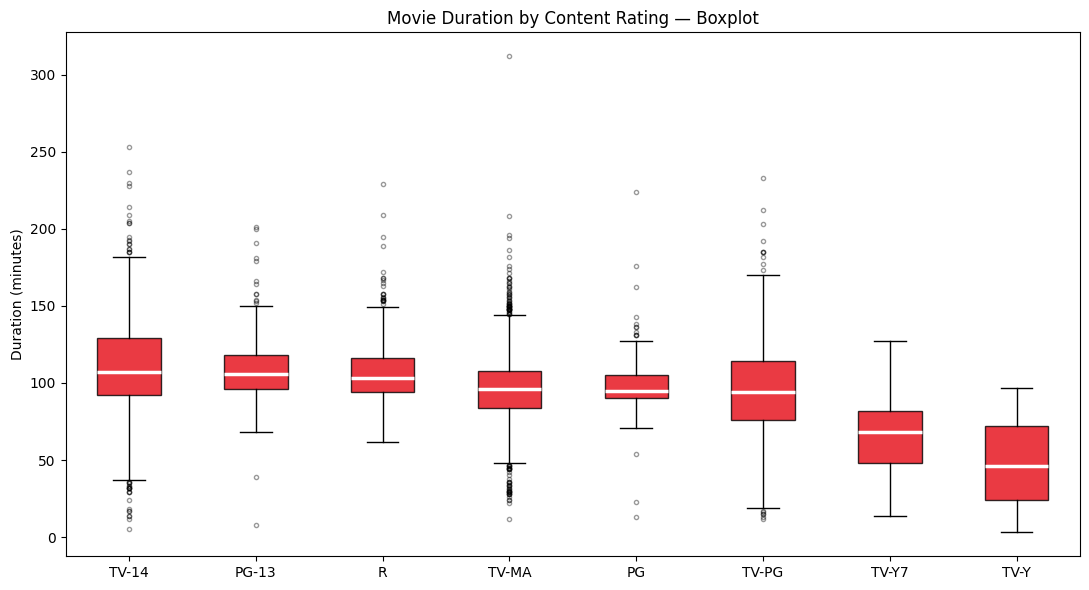

In [ ]:
movies = df[df['type'] == 'Movie'].copy()
movies['minutes'] = movies['duration'].str.extract(r'(\d+)').astype(float)
top_ratings = movies['rating'].value_counts().head(8).index
movies_r = movies[movies['rating'].isin(top_ratings)].dropna(subset=['minutes'])
rating_order = movies_r.groupby('rating')['minutes'].median() \
                        .sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(11,6))
bp = ax.boxplot(
    [movies_r[movies_r['rating']==r]['minutes'].values for r in rating_order],
    labels=rating_order, patch_artist=True,
    medianprops=dict(color='white', linewidth=2.5),
    flierprops=dict(marker='o', color='#E50914', markersize=3, alpha=0.4)
)
for patch in bp['boxes']:
    patch.set_facecolor('#E50914'); patch.set_alpha(0.8)
ax.set_title('Movie Duration by Content Rating — Boxplot')
ax.set_ylabel('Duration (minutes)')
plt.tight_layout(); plt.show()

12. Heatmap — Monthly Content Additions

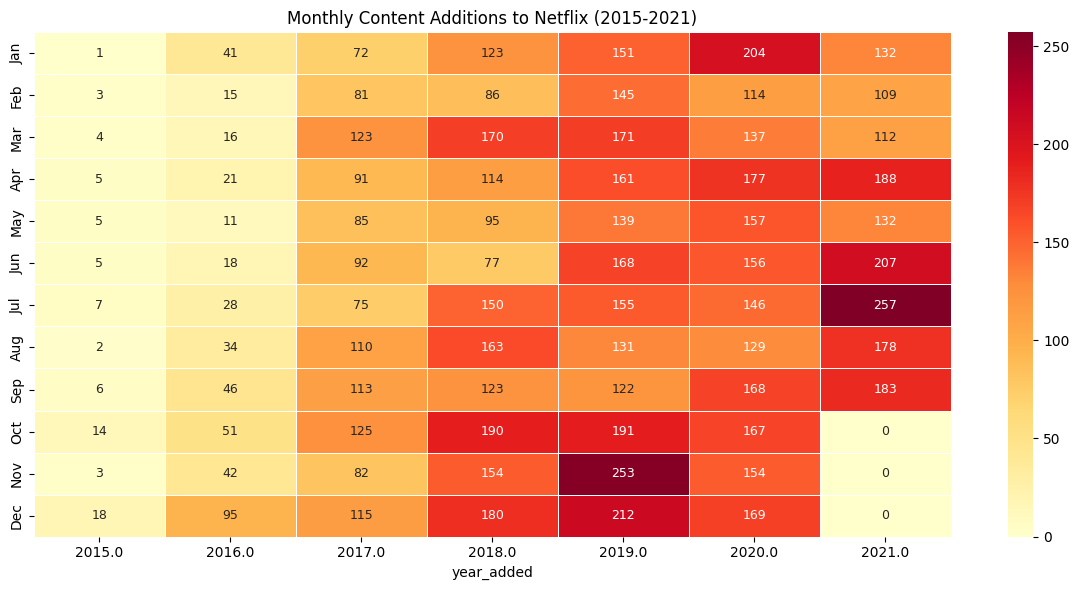

In [ ]:
heat = df.dropna(subset=['year_added','month_added'])
heat = heat[heat['year_added'] >= 2015]
pivot = heat.pivot_table(index='month_added', columns='year_added',
                          values='show_id', aggfunc='count', fill_value=0)
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12,6))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.5,
            annot=True, fmt='d', annot_kws={'size':9})
ax.set_title('Monthly Content Additions to Netflix (2015-2021)')
plt.tight_layout(); plt.show()

15. Scatter — Release Year vs Duration with Trend

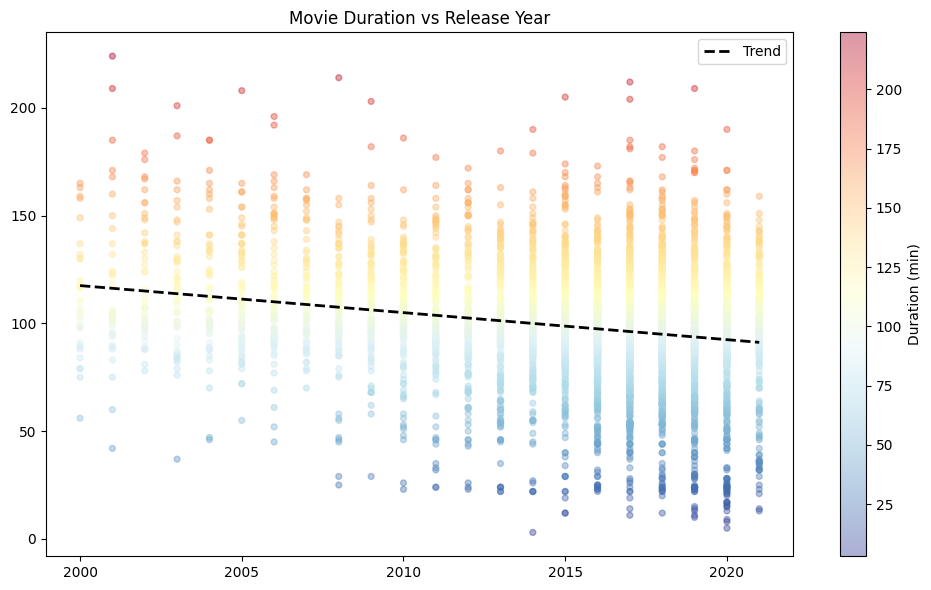

In [ ]:
sc_data = movies.dropna(subset=['minutes','release_year'])
sc_data = sc_data[(sc_data['release_year']>=2000) & (sc_data['minutes']<250)]

fig, ax = plt.subplots(figsize=(10,6))
sc = ax.scatter(sc_data['release_year'], sc_data['minutes'],
    c=sc_data['minutes'], cmap='RdYlBu_r', alpha=0.4, s=18)
z = np.polyfit(sc_data['release_year'], sc_data['minutes'], 1)
xp = np.linspace(sc_data['release_year'].min(), sc_data['release_year'].max(), 100)
ax.plot(xp, np.poly1d(z)(xp), color='black', linewidth=2, linestyle='--', label='Trend')
plt.colorbar(sc, ax=ax, label='Duration (min)')
ax.set_title('Movie Duration vs Release Year')
ax.legend(); plt.tight_layout(); plt.show()

17. Bubble Chart — Country × Avg Duration × Volume

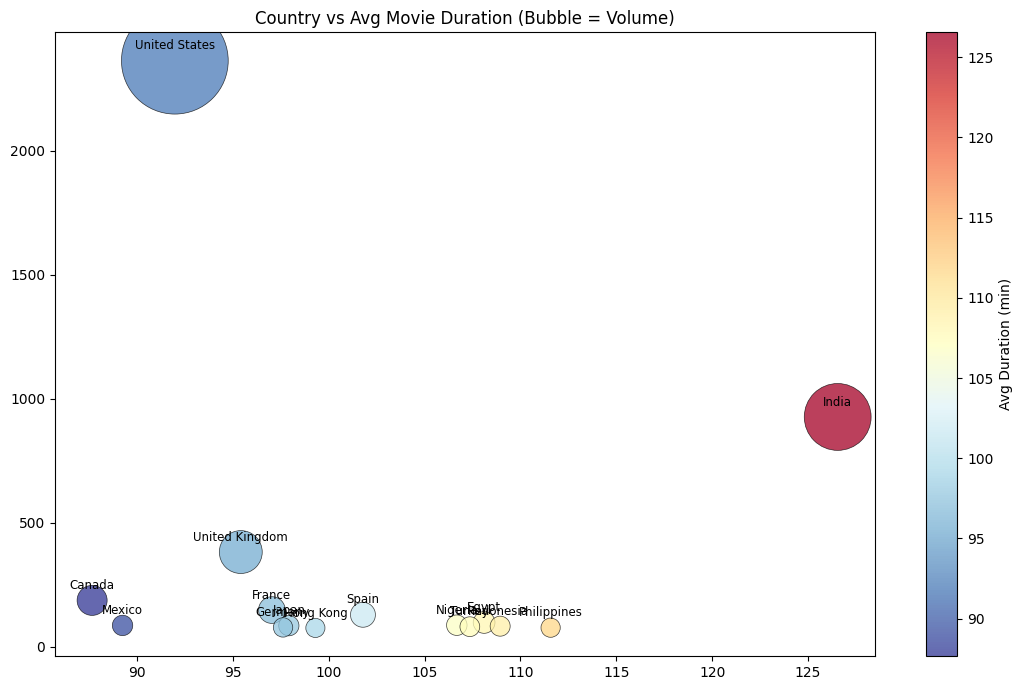

In [ ]:
movies['country_first'] = movies['country'].str.split(',').str[0].str.strip()
cg = movies.groupby('country_first').agg(
    count=('title','count'), avg_dur=('minutes','mean')).reset_index()
cg = cg[cg['count'] >= 30].sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11,7))
sc = ax.scatter(cg['avg_dur'], cg['count'],
    s=cg['count']*2.5, c=cg['avg_dur'], cmap='RdYlBu_r',
    alpha=0.75, edgecolors='black', linewidths=0.5)
for _, row in cg.iterrows():
    ax.annotate(row['country_first'], (row['avg_dur'], row['count']),
        fontsize=8.5, ha='center', va='bottom', xytext=(0,6),
        textcoords='offset points')
plt.colorbar(sc, ax=ax, label='Avg Duration (min)')
ax.set_title('Country vs Avg Movie Duration (Bubble = Volume)')
plt.tight_layout(); plt.show()


18. Grouped Bar — Movies vs TV Shows by Top 5 Countries

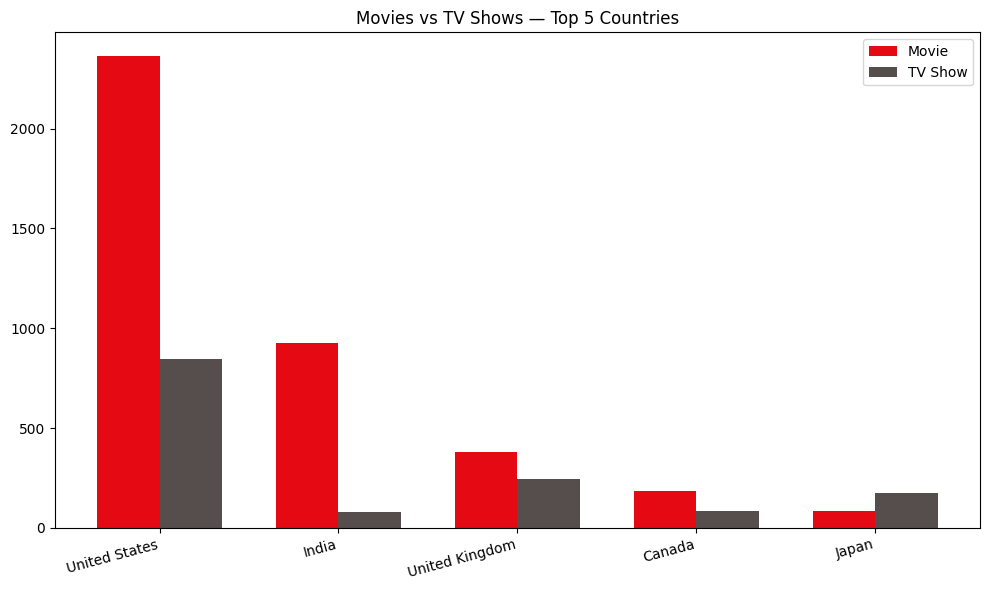

In [ ]:
df['country_first'] = df['country'].str.split(',').str[0].str.strip()
top5_c = df['country_first'].value_counts().head(5).index
pivot_ct = df[df['country_first'].isin(top5_c)] \
              .groupby(['country_first','type']).size() \
              .unstack(fill_value=0).loc[top5_c]

x = np.arange(len(pivot_ct)); w = 0.35
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - w/2, pivot_ct['Movie'],   width=w, color='#E50914', label='Movie')
ax.bar(x + w/2, pivot_ct['TV Show'], width=w, color='#564d4d', label='TV Show')
ax.set_xticks(x); ax.set_xticklabels(pivot_ct.index, rotation=15, ha='right')
ax.set_title('Movies vs TV Shows — Top 5 Countries')
ax.legend(); plt.tight_layout(); plt.show()
